In [73]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [74]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

.\MegaSena_CSVDataset.ipynb
.\MegaSena_Dezena.csv
.\MegaSena_Dezena.ipynb
.\MegaSena_Dezena_CRS.csv
.\MegaSena_Dezena_CSV.ipynb
.\MegaSena_Dezena_Sorteio.csv
.\MegaSena_Dezena_SRT.csv
.\MegaSena_Predict.csv
.\MegaSena_Predict.ipynb
.\MegaSena_Torch_CSV.ipynb
.\MegaSena_Torch_MLP.csv
.\MegaSena_Torch_MLP.ipynb
.\mega_sena_asloterias_ate_concurso_2404_crescente.xlsx
.\mega_sena_asloterias_ate_concurso_2404_sorteio.xlsx
.\mega_sena_crescente.csv
.\mega_sena_sorteio.csv


In [75]:
#filepath = './MegaSena_Dezena_CRS.csv'
#filepath = './MegaSena_Dezena_SRT.csv'
filepath = './MegaSena_Dezena_SRT.csv'
data = pd.read_csv(filepath)
data = data.sort_values('Date')
data.head()
data.tail()

,Sequence,Date,Value1,Value2,Value3,Value4,Value5,Value6
0,1,1996-03-11,41,5,4,52,30,33
1,2,1996-03-18,9,39,37,49,43,41
2,3,1996-03-25,36,30,10,11,29,47
3,4,1996-04-01,6,59,42,27,1,5
4,5,1996-04-08,1,19,46,6,16,2


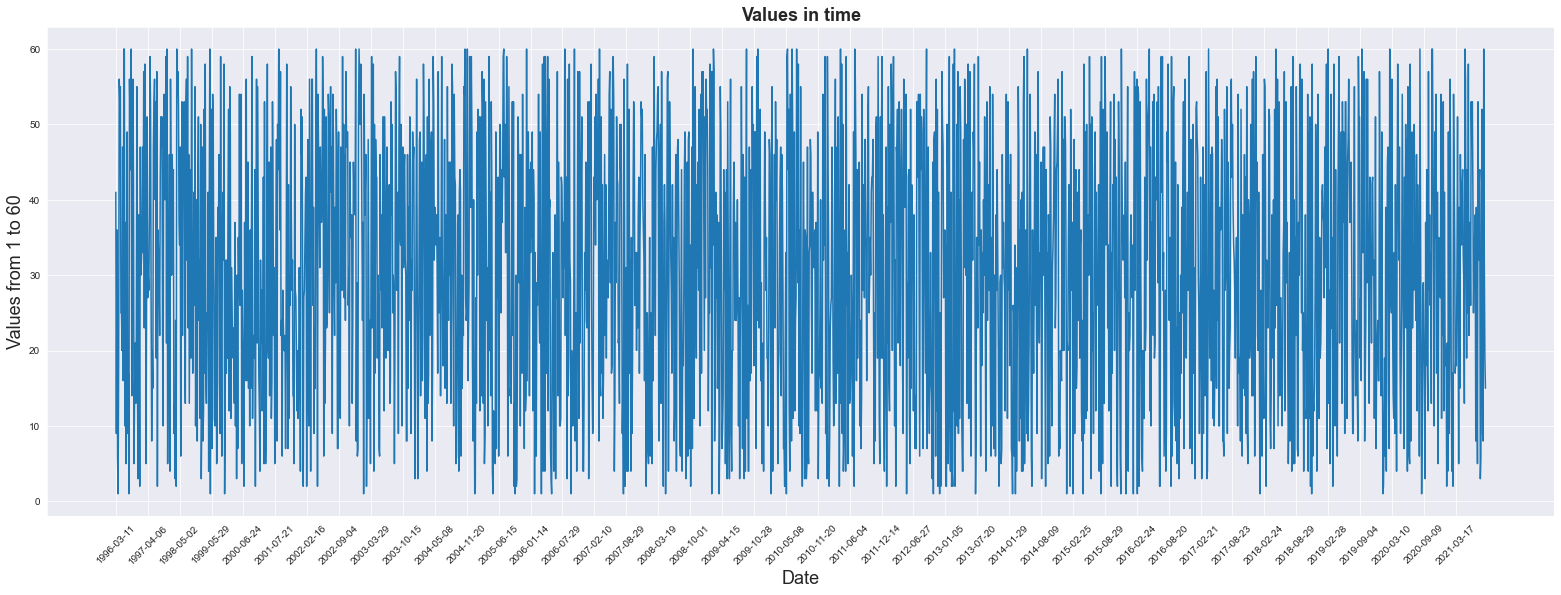

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.figure(figsize = (27,9))
newvalue = 'Value1'
plt.plot(data[[newvalue]])
plt.xticks(range(0,data.shape[0],56),data['Date'].loc[::56],rotation=45)
plt.title("Values in time",fontsize=18, fontweight='bold')
plt.xlabel('Date',fontsize=18)
plt.ylabel('Values from 1 to 60',fontsize=18)
plt.show()

In [77]:
price = data[[newvalue]]
price.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2405 entries, 0 to 2404
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Value1  2405 non-null   int64
dtypes: int64(1)
memory usage: 37.6 KB


In [78]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
price[newvalue] = scaler.fit_transform(price[newvalue].values.reshape(-1,1))

C:\Windows\TEMP/ipykernel_9388/3707366084.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [79]:
def split_data(stock, lookback):
    data_raw = stock.to_numpy() # convert to numpy array
    data = []
    
    # create all possible sequences of length seq_len
    for index in range(len(data_raw) - lookback): 
        data.append(data_raw[index: index + lookback])
    
    data = np.array(data)
    test_set_size = int(np.round(0.2*data.shape[0]))
    train_set_size = data.shape[0] - (test_set_size)
    
    x_train = data[:train_set_size,:-1,:]
    y_train = data[:train_set_size,-1,:]
    
    x_test = data[train_set_size:,:-1]
    y_test = data[train_set_size:,-1,:]
    
    return [x_train, y_train, x_test, y_test]

In [80]:
lookback = 20 # choose sequence length
x_train, y_train, x_test, y_test = split_data(price, lookback)
print('x_train.shape = ',x_train.shape)
print('y_train.shape = ',y_train.shape)
print('x_test.shape = ',x_test.shape)
print('y_test.shape = ',y_test.shape)

x_train.shape =  (1908, 19, 1)
y_train.shape =  (1908, 1)
x_test.shape =  (477, 19, 1)
y_test.shape =  (477, 1)


In [81]:
import torch
import torch.nn as nn

x_train = torch.from_numpy(x_train).type(torch.Tensor)
x_test = torch.from_numpy(x_test).type(torch.Tensor)
y_train_lstm = torch.from_numpy(y_train).type(torch.Tensor)
y_test_lstm = torch.from_numpy(y_test).type(torch.Tensor)
y_train_gru = torch.from_numpy(y_train).type(torch.Tensor)
y_test_gru = torch.from_numpy(y_test).type(torch.Tensor)

In [82]:
input_dim = 1
hidden_dim = 32
num_layers = 2
output_dim = 1
num_epochs = 350

In [83]:
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

In [84]:
model = LSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
criterion = torch.nn.MSELoss(reduction='mean')
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

In [85]:
import time

hist = np.zeros(num_epochs)
start_time = time.time()
lstm = []

for t in range(num_epochs):
    y_train_pred = model(x_train)

    loss = criterion(y_train_pred, y_train_lstm)
    print("Epoch ", t, "MSE: ", loss.item())
    hist[t] = loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()
    
training_time = time.time()-start_time
print("Training time: {}".format(training_time))

Epoch  0 MSE:  0.34596389532089233
Epoch  1 MSE:  0.36781564354896545
Epoch  2 MSE:  0.3468867838382721
Epoch  3 MSE:  0.3477921485900879
Epoch  4 MSE:  0.35135337710380554
Epoch  5 MSE:  0.3505987524986267
Epoch  6 MSE:  0.348270982503891
Epoch  7 MSE:  0.34639373421669006
Epoch  8 MSE:  0.34569665789604187
Epoch  9 MSE:  0.3461405336856842
Epoch  10 MSE:  0.34686896204948425
Epoch  11 MSE:  0.3469758927822113
Epoch  12 MSE:  0.34653791785240173
Epoch  13 MSE:  0.34602558612823486
Epoch  14 MSE:  0.3457140624523163
Epoch  15 MSE:  0.34563571214675903
Epoch  16 MSE:  0.34570860862731934
Epoch  17 MSE:  0.3458314836025238
Epoch  18 MSE:  0.34592634439468384
Epoch  19 MSE:  0.3459515869617462
Epoch  20 MSE:  0.34590089321136475
Epoch  21 MSE:  0.3457939922809601
Epoch  22 MSE:  0.3456646800041199
Epoch  23 MSE:  0.34554824233055115
Epoch  24 MSE:  0.3454713225364685
Epoch  25 MSE:  0.34544527530670166
Epoch  26 MSE:  0.3454633951187134
Epoch  27 MSE:  0.3455042839050293
Epoch  28 MSE:  0

In [86]:
predict = pd.DataFrame(scaler.inverse_transform(y_train_pred.detach().numpy()))
original = pd.DataFrame(scaler.inverse_transform(y_train_lstm.detach().numpy()))

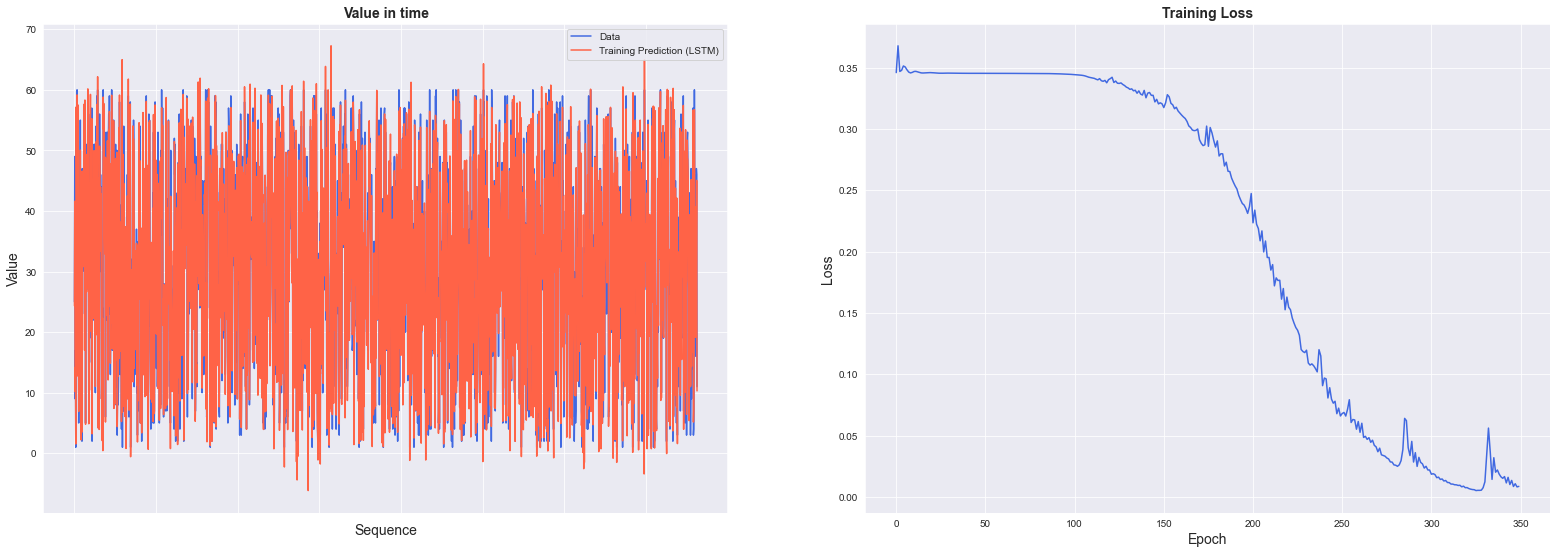

In [87]:
import seaborn as sns
sns.set_style("darkgrid")    

fig = plt.figure()
fig.subplots_adjust(hspace=0.2, wspace=0.2)

plt.subplot(1, 2, 1)
ax = sns.lineplot(x = original.index, y = original[0], label="Data", color='royalblue')
ax = sns.lineplot(x = predict.index, y = predict[0], label="Training Prediction (LSTM)", color='tomato')
ax.set_title('Value in time', size = 14, fontweight='bold')
ax.set_xlabel("Sequence", size = 14)
ax.set_ylabel("Value", size = 14)
ax.set_xticklabels('', size=10)

plt.subplot(1, 2, 2)
ax = sns.lineplot(data=hist, color='royalblue')
ax.set_xlabel("Epoch", size = 14)
ax.set_ylabel("Loss", size = 14)
ax.set_title("Training Loss", size = 14, fontweight='bold')
fig.set_figheight(9)
fig.set_figwidth(27)

In [88]:
import math, time
from sklearn.metrics import mean_squared_error

# make predictions
y_test_pred = model(x_test)

# invert predictions
y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
y_train = scaler.inverse_transform(y_train_lstm.detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())
y_test = scaler.inverse_transform(y_test_lstm.detach().numpy())

# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(y_test[:,0], y_test_pred[:,0]))
print('Test Score: %.2f RMSE' % (testScore))
lstm.append(trainScore)
lstm.append(testScore)
lstm.append(training_time)

Train Score: 2.74 RMSE
Test Score: 23.98 RMSE


In [109]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(price)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[lookback:len(y_train_pred)+lookback, :] = y_train_pred

# shift test predictions for plotting
testPredictPlot = np.empty_like(price)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(y_train_pred)+lookback-1:len(price)-1, :] = y_test_pred

original = scaler.inverse_transform(price[newvalue].values.reshape(-1,1))

predictions = np.append(trainPredictPlot, testPredictPlot, axis=1)
predictions = np.append(predictions, original, axis=1)
result = pd.DataFrame(predictions)

result.head(10)
result.tail(10)

,0,1,2
2395,NaN,40.456650,3.0
2396,NaN,51.206276,6.0
2397,NaN,80.886536,36.0
2398,NaN,79.344627,52.0
2399,NaN,19.351976,9.0
2400,NaN,16.062803,8.0
2401,NaN,34.008678,60.0
2402,NaN,24.419727,32.0
2403,NaN,19.064796,19.0
2404,NaN,NaN,15.0


In [90]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[0],
                    mode='lines',
                    name='Train prediction')))
fig.add_trace(go.Scatter(x=result.index, y=result[1],
                    mode='lines',
                    name='Test prediction'))
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[2],
                    mode='lines',
                    name='Actual Value')))
fig.update_layout(
    xaxis=dict(showline=True, showgrid=True, showticklabels=False, linecolor='white', linewidth=2),
    yaxis=dict(title_text='Value', 
        titlefont=dict(family='Rockwell', size=12, color='white'),
        showline=True,
        showgrid=True,
        showticklabels=True,
        linecolor='white',
        linewidth=2,
        ticks='outside',
        tickfont=dict(family='Rockwell', size=12, color='white')),
    showlegend=True,
    template = 'plotly_dark')

annotations = []
annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05,
                        xanchor='left', yanchor='bottom',
                        text='Results (LSTM)',
                        font=dict(family='Rockwell',
                                  size=26,
                                  color='white'),
                                  showarrow=False))
fig.update_layout(annotations=annotations)
fig.show()

In [92]:
class GRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(GRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn) = self.gru(x, (h0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

In [93]:
model = GRU(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
criterion = torch.nn.MSELoss(reduction='mean')
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

In [94]:
hist = np.zeros(num_epochs)
start_time = time.time()
gru = []

for t in range(num_epochs):
    y_train_pred = model(x_train)

    loss = criterion(y_train_pred, y_train_gru)
    print("Epoch ", t, "MSE: ", loss.item())
    hist[t] = loss.item()

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

training_time = time.time()-start_time    
print("Training time: {}".format(training_time))

Epoch  0 MSE:  0.3938502073287964
Epoch  1 MSE:  0.36222660541534424
Epoch  2 MSE:  0.3595554232597351
Epoch  3 MSE:  0.34656766057014465
Epoch  4 MSE:  0.34688931703567505
Epoch  5 MSE:  0.350721538066864
Epoch  6 MSE:  0.35125961899757385
Epoch  7 MSE:  0.34907981753349304
Epoch  8 MSE:  0.3466339409351349
Epoch  9 MSE:  0.3454340696334839
Epoch  10 MSE:  0.34569448232650757
Epoch  11 MSE:  0.34667497873306274
Epoch  12 MSE:  0.3473495841026306
Epoch  13 MSE:  0.3472204804420471
Epoch  14 MSE:  0.34652945399284363
Epoch  15 MSE:  0.34580525755882263
Epoch  16 MSE:  0.34540995955467224
Epoch  17 MSE:  0.34540730714797974
Epoch  18 MSE:  0.3456544578075409
Epoch  19 MSE:  0.3459462523460388
Epoch  20 MSE:  0.3461218476295471
Epoch  21 MSE:  0.3461138904094696
Epoch  22 MSE:  0.345946341753006
Epoch  23 MSE:  0.3457021713256836
Epoch  24 MSE:  0.34547901153564453
Epoch  25 MSE:  0.3453499972820282
Epoch  26 MSE:  0.34533941745758057
Epoch  27 MSE:  0.34541937708854675
Epoch  28 MSE:  0.

In [95]:
predict = pd.DataFrame(scaler.inverse_transform(y_train_pred.detach().numpy()))
original = pd.DataFrame(scaler.inverse_transform(y_train_gru.detach().numpy()))

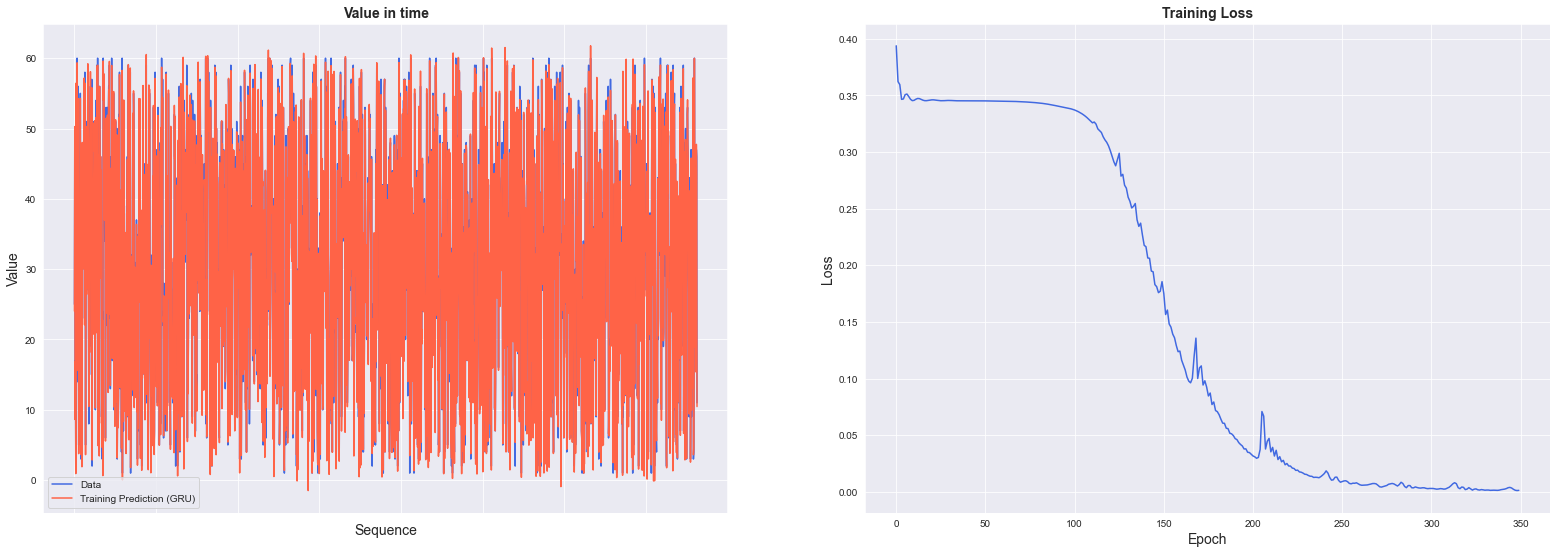

In [96]:
import seaborn as sns
sns.set_style("darkgrid")    

fig = plt.figure()
fig.subplots_adjust(hspace=0.2, wspace=0.2)

plt.subplot(1, 2, 1)
ax = sns.lineplot(x = original.index, y = original[0], label="Data", color='royalblue')
ax = sns.lineplot(x = predict.index, y = predict[0], label="Training Prediction (GRU)", color='tomato')
ax.set_title('Value in time', size = 14, fontweight='bold')
ax.set_xlabel("Sequence", size = 14)
ax.set_ylabel("Value", size = 14)
ax.set_xticklabels('', size=10)


plt.subplot(1, 2, 2)
ax = sns.lineplot(data=hist, color='royalblue')
ax.set_xlabel("Epoch", size = 14)
ax.set_ylabel("Loss", size = 14)
ax.set_title("Training Loss", size = 14, fontweight='bold')
fig.set_figheight(9)
fig.set_figwidth(27)

In [97]:
import math, time
from sklearn.metrics import mean_squared_error

# make predictions
y_test_pred = model(x_test)

# invert predictions
y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
y_train = scaler.inverse_transform(y_train_gru.detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())
y_test = scaler.inverse_transform(y_test_gru.detach().numpy())

# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(y_test[:,0], y_test_pred[:,0]))
print('Test Score: %.2f RMSE' % (testScore))
gru.append(trainScore)
gru.append(testScore)
gru.append(training_time)
print('Training Time: %.2f RMSE' % (training_time))


Train Score: 1.07 RMSE
Test Score: 28.14 RMSE
Training Time: 32.14 RMSE


In [107]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(price)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[lookback:len(y_train_pred)+lookback, :] = y_train_pred

# shift test predictions for plotting
testPredictPlot = np.empty_like(price)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(y_train_pred)+lookback-1:len(price)-1, :] = y_test_pred

original = scaler.inverse_transform(price[newvalue].values.reshape(-1,1))

predictions = np.append(trainPredictPlot, testPredictPlot, axis=1)
predictions = np.append(predictions, original, axis=1)
result = pd.DataFrame(predictions)
result.head(10)
result.tail(10)

,0,1,2
2395,NaN,40.456650,3.0
2396,NaN,51.206276,6.0
2397,NaN,80.886536,36.0
2398,NaN,79.344627,52.0
2399,NaN,19.351976,9.0
2400,NaN,16.062803,8.0
2401,NaN,34.008678,60.0
2402,NaN,24.419727,32.0
2403,NaN,19.064796,19.0
2404,NaN,NaN,15.0


In [99]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[0], mode='lines', name='Train prediction')))
fig.add_trace(go.Scatter(x=result.index, y=result[1], mode='lines', name='Test prediction'))
fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[2], mode='lines', name='Actual Value')))
fig.update_layout(xaxis=dict(showline=True, showgrid=True, showticklabels=False, linecolor='white', linewidth=2),
                  yaxis=dict(title_text='Value', 
                     titlefont=dict(family='Rockwell', size=12, color='white'),
                     showline=True,
                     showgrid=True,
                     showticklabels=True,
                     linecolor='white',
                     linewidth=2,
                     ticks='outside',
                     tickfont=dict(family='Rockwell', size=12, color='white')),
                     showlegend=True,
                     template = 'plotly_dark')
annotations = []
annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05, xanchor='left', yanchor='bottom', text='Results (GRU)',
                        font=dict(family='Rockwell', size=26, color='white'),
                        showarrow=False))
fig.update_layout(annotations=annotations)
fig.show()

In [108]:
lstm = pd.DataFrame(lstm, columns=['LSTM'])
gru = pd.DataFrame(gru, columns=['GRU'])
result = pd.concat([lstm, gru], axis=1, join='inner')
result.index = ['Train RMSE', 'Test RMSE', 'Train Time']
result

,LSTM,GRU
Train RMSE,2.735315,1.072110
Test RMSE,23.979746,28.140570
Train Time,41.302200,32.142824
